### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
api_wrapper = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("What are the latest papers on deep learning?")

'Published: 2023-01-03\nTitle: Deep Learning and Computational Physics (Lecture Notes)\nAuthors: Deep Ray, Orazio Pinti, Assad A. Oberai\nSummary: These notes were compiled as lecture notes for a course developed and taught at the University of the Southern California. They should be accessible to a typical engineering graduate student with a strong background in Applied Mathematics.\n  The main objective of these notes is to introduce a student who is familiar with concepts in linear algebra and par'

In [4]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=100)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [5]:
wiki.invoke("What is LangGraph?")

'Page: List of unsolved problems in mathematics\nSummary: Many mathematical problems have been stated '

In [6]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [7]:
## Getting Tavily Search Results
from langchain_community.tools import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\HP\AppData\Local\Temp\ipykernel_7476\3506208815.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [8]:
tavily.invoke("What is the latest news on AI?")

[{'title': 'The Latest AI News and Breakthroughs That Matter Most | News',
  'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates',
  'content': 'Date: May 21, 2026\n\nSummary: SoundHound AI announced the acquisition of conversational AI platform LivePerson, combining its voice and audio recognition capabilities with LivePerson\'s digital messaging products. Management has set 2027 revenue targets of $350 million to $400 million and identified a $500 million cross-selling opportunity across the combined customer base. The deal positions SoundHound to compete more directly with Microsoft, Google, and Amazon across enterprise contact centers, healthcare, and financial services.\n\nSource: Simply Wall St ↗\n\n### (AI News) Nvidia\'s Memory Costs Soar 485% as Latest AI Systems Now Cost $7.8 Million to Build\n\nDate: May 21, 2026 [...] Source: Insurance Business Magazine\n\n### (AI Controversy) Trump Administration Disables Anthropic\'s Claude Fable 5 and Mythos 5 Models\n\nDate

In [9]:
### Combine all the tools in the list

tools = [arxiv, wiki, tavily]

In [10]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="Llama-3.1-8b-instant")

llm_with_tools=llm.bind_tools(tools)

e:\GitHub\Python\Python_Agentic_AI_With_Langchain_and_Langraph\practice_agentic_ai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

llm_with_tools.invoke([HumanMessage(content=f"What is the recent Global News")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'g716sys9p', 'function': {'arguments': '{"query":"Global News"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 553, 'total_tokens': 572, 'completion_time': 0.025950049, 'completion_tokens_details': None, 'prompt_time': 0.0373227, 'prompt_tokens_details': None, 'queue_time': 0.04799004, 'total_time': 0.063272749}, 'model_name': 'Llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee117-d103-7c62-aefe-93c6eeb4f825-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Global News'}, 'id': 'g716sys9p', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 553, 'output_tokens': 19, 'total_tokens': 572})

In [12]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent Global News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'Global News'},
  'id': '5r9dyn3kt',
  'type': 'tool_call'}]

## ENTIRE CHAT GRAPH

In [13]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

In [15]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


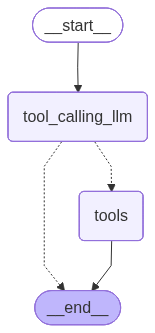

In [17]:

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================

<arxiv query="1706.03762"></arxiv>


In [19]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (z4d44e5g7)
 Call ID: z4d44e5g7
  Args:
    query: AI news March 3rd 2025
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "March 2025 - The Artificial Intelligence Revolution - Choreo", "url": "https://choreoadvisors.com/market-perspectives/march-2025-the-artificial-intelligence-revolution", "content": "There are plenty of signs that AI is beginning to have a material effect on the world. One of the early signals may be the valuation of AI-related private companies such as OpenAI. Investors are willing to pay up for what they believe could be a potential leader in the field. The ChatGPT maker’s most recent funding round in the private markets valued the 